In [1]:
# IMPORT LIBRARIES
# ------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
#model_selection → module for splitting data.
#train_test_split() → function to divide dataset. Machine learning needs: training data ,testing data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression#This model learns relationship between: input features ,house prices
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

print("First 5 Rows of Dataset:\n")
print(df.head())

First 5 Rows of Dataset:

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [4]:
print("\nDataset Information:\n")
print(df.info())


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None


In [5]:
print("\nStatistical Summary:\n")
print(df.describe())


Statistical Summary:

             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio           b  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std 

In [6]:
print("\nShape of Dataset:")
print(df.shape)


Shape of Dataset:
(506, 14)


In [7]:
print("\nColumns in Dataset:")
print(df.columns)


Columns in Dataset:
Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')


In [8]:
print("\nCheck Missing Values:\n")
print(df.isnull().sum())


Check Missing Values:

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [9]:
# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

In [10]:
# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

In [11]:
print("\nData Types:\n")
print(df.dtypes)


Data Types:

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object


In [12]:
# SPLIT DATA Input data should NOT contain target column.
X = df.drop('medv', axis=1)   # Features
y = df['medv']                
# Target (house price)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42#Ensures same output every run.
)

In [13]:
# TRAIN MODEL Creates Linear Regression object.
model = LinearRegression()
model.fit(X_train, y_train)#Model learns patterns from data.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# PREDICTION Uses learned patterns to predict new prices.
y_pred = model.predict(X_test)

In [15]:
# EVALUATION Measures prediction error.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)#Converts error back to original units.
r2 = r2_score(y_test, y_pred)#Measures model accuracy.
print("\nModel Evaluation:")
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)


Model Evaluation:
Mean Squared Error: 24.29111947497345
Root Mean Squared Error: 4.92860218266533
R² Score: 0.6687594935356329


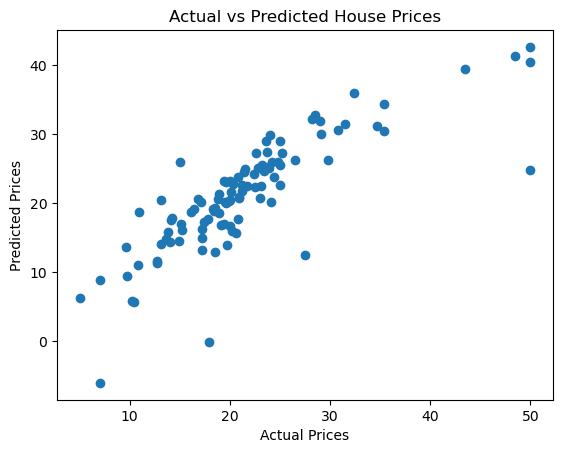

In [17]:
plt.figure()
plt.scatter(y_test, y_pred)#Compares actual vs predicted values.
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()